In [ ]:
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Converted from data.csv - 2025, 2024, 2023 Financial Analysis
df = pd.read_csv('data.csv')

In [17]:
# Data Cleaning & Preparation
# Calculating Revenue Growth Rates & Net Income Growth Rates
df['Revenue Growth (%)'] = df.groupby('Company Name')['Total Revenue'].pct_change() * 100
df['Net Income Growth (%)'] = df.groupby('Company Name')['Total Income'].pct_change() * 100

In [24]:
# Calculating Profit Margins and Debt Ratios
df['Profit_Margin_%'] = (df['Total Income'] / df['Total Revenue']) * 100
df['Debt_to_Asset_Ratio'] = df['Total Liabilities'] / df['Total Asset']

In [25]:
# Generating Insights for the Chatbot Knowledge Base
print("--- Financial Insights Database ---\n")
for company in df['Company Name'].unique():
    comp_data = df[df['Company Name'] == company].iloc[-1] # Get latest year (2025)
    print(f"[{company} - FY2025 Context]")
    print(f"Revenue: ${comp_data['Total Revenue']:,.0f}M (Growth: {comp_data['Revenue Growth (%)']:.2f}%)")
    print(f"Net Income: ${comp_data['Total Income']:,.0f}M (Margin: {comp_data['Profit_Margin_%']:.2f}%)")
    print(f"Debt-to-Asset Ratio: {comp_data['Debt_to_Asset_Ratio']:.2f}\n")

--- Financial Insights Database ---

[Microsoft - FY2025 Context]
Revenue: $211,915M (Growth: -13.55%)
Net Income: $72,361M (Margin: 34.15%)
Debt-to-Asset Ratio: 0.50

[Tesla - FY2025 Context]
Revenue: $96,773M (Growth: -0.94%)
Net Income: $14,974M (Margin: 15.47%)
Debt-to-Asset Ratio: 0.40

[Apple - FY2025 Context]
Revenue: $383,285M (Growth: -1.98%)
Net Income: $96,995M (Margin: 25.31%)
Debt-to-Asset Ratio: 0.82



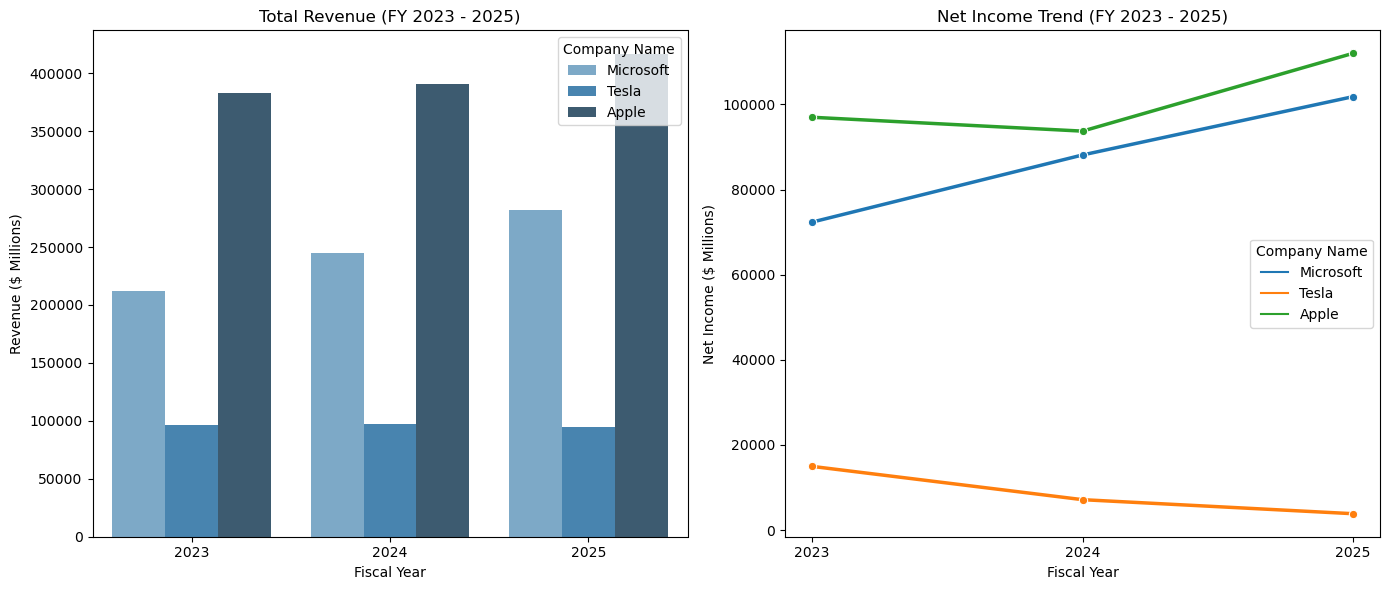

In [14]:
# Visualization (Revenue & Net Income Trends)
plt.figure(figsize=(14, 6))

# Revenue Plot
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Fiscal Year', y='Total Revenue', hue='Company Name', palette='Blues_d')
plt.title('Total Revenue (FY 2023 - 2025)')
plt.ylabel('Revenue ($ Millions)')
plt.xlabel('Fiscal Year')

# Net Income Plot
plt.subplot(1, 2, 2)
sns.lineplot(data=df, x='Fiscal Year', y='Total Income', hue='Company Name', marker='o', linewidth=2.5)
plt.title('Net Income Trend (FY 2023 - 2025)')
plt.ylabel('Net Income ($ Millions)')
plt.xlabel('Fiscal Year')
plt.xticks([2023, 2024, 2025])

plt.tight_layout()
plt.show()